# [The StatQuest Illustrated Guide to Statistics](https://www.amazon.com/dp/B0GMP7Z9ZL)
## Chapter 02 - Visualizing Data and Calculating Probabilities with Histograms!!!!!!

Copyright 2026, Joshua Starmer

In this notebook we'll learn how to...

- Learn how to build a histogram with the Number of Apples for sale at each **Spend-n-Save** store. We'll also learn how to save the histogram as a **PDF** file.
- Learn how to change the histogram's bin sizes and see the effect that this has on the insights we can make from the data.
- Learn how to calculate probabilities from the data.
- Lastly, as a bonus, we'll draw histograms of the **Estimated Standard Deviations** that we calculated at the end of the coding exercises for Chapter 1.

**NOTE:**
This tutorial assumes that you have installed **[Python](https://www.python.org/)** and read Chapter 2 in **[The StatQuest Illustrated Guide to Statistics](https://www.amazon.com/dp/B0GMP7Z9ZL)**.

----

# Load the Spend-n-Save data and use it to draw a histogram

Just like we did in the exercises for Chapter 1, we start by loading in the **Spend-n-Save** data. However, before we get to that, we have to load in some modules that will help us load data and do math.

In [1]:
import pandas as pd # to import data into a dataframe
import seaborn as sns # to draw a histogram and have it look somewhat nice
import numpy as np # to determine bin sizes and help make things reproducable
import statistics # to calculate mean and standard deviation

Now let's load in the **Spend-n-Save** data.

In [2]:
## First, use pd.read_csv() to read the data in "spend_n_save.txt"
spend_n_save_df = pd.read_csv("https://raw.githubusercontent.com/StatQuest/sigs/refs/heads/main/chapter_01/spend_n_save.txt", sep="\t")

# Verify that read_csv() was successful by printing out the first few rows
spend_n_save_df.head()

,id,num.apples
0,1,27
1,2,17
2,3,22
3,4,23
4,5,22


Now, one problem with our data is that the second column is called `num.apples`, with a dot, `.`, between `num` and `apples`. This dot will get in our way later on, so let's replace it with an underscore, `_`.

In [3]:
## rename num.apples to num_apples so it's easier to access the values
spend_n_save_df.rename(columns={'num.apples': 'num_apples'}, inplace=True)

## print out first few rows to verify the rename
spend_n_save_df.head()

,id,num_apples
0,1,27
1,2,17
2,3,22
3,4,23
4,5,22


Now that we have the data, we can use the `sns.histplot()` function to draw a histogram of the Number of Apples for sale at each store.

<Axes: xlabel='num_apples', ylabel='Count'>

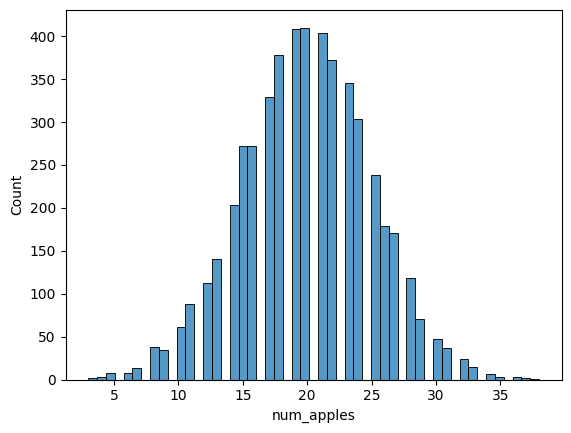

In [4]:
## using the default method for finding optimal bins
sns.histplot(data=spend_n_save_df, x='num_apples')

# BAM?

Well, by default, `sns.histplot()` does its best to find a reasonable width and number of bins for the histogram. However, as you can see, it doesn't always do a great job. The default settings show the underlying trends in the data, but there are gaps that make it looks strange. We can fix this by either trying to set the number of bins manually, which we'll do in a bit, or we can suggest that `sns.histplot()` use a different algorithm for figuring out what to do with the bins, which we'll do right now.

To tell `sns.histplot()` to use a different algorithm to figure out the bins, we simply set the `bins` parameter to the name of the algorithm we want to use. There are a **[bunch of diffrent algorithms to chose from](https://numpy.org/doc/stable/reference/generated/numpy.histogram_bin_edges.html#numpy.histogram_bin_edges)**, so feel free to test them all out. However, for now we'll just see what happens when we set `bins='scott`'.

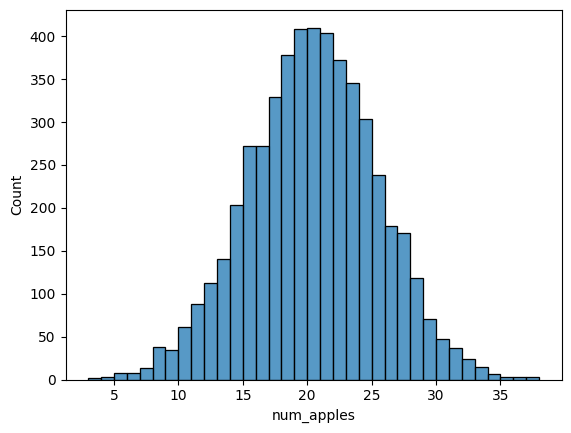

In [5]:
## Calculate bin edges using a specific rule by setting the 'bins' parameter
## Other options 'sturges', 'sqrt', and several more.
my_hist = sns.histplot(data=spend_n_save_df, x='num_apples', bins='scott')

# BAM!

Now let's save the histogram as a **PDF** file. We do this by extracting the figure from `my_hist` with the `get_figure()` method...

In [6]:
## extract the figure from our histogram...
fig = my_hist.get_figure()

...and then calling `savefig()` with the filename we want to use, `spend_n_save_histogram.pdf`. **NOTE:** By ending the file name with the `.pdf` suffix, the we'll end up with a **PDF** file. However, we can also save the file as a **PNG** by using the `.png` suffix.

In [7]:
## Save the figure as a PDF file
fig.savefig('spend_n_save_histogram.pdf') 

Now that we know how to create a basic histogram and save the graph to a **PDF**, let's learn how we can modify the bin sizes and see what effects that has on how we can interpret the data.

----

# Manually change the bin sizes.

Instead of relying on an algorithm to find the best bin sizes, we can also just manually determine the number of bins by setting `bins` to a number. We'll start by setting `bins=2`.

<Axes: xlabel='num_apples', ylabel='Count'>

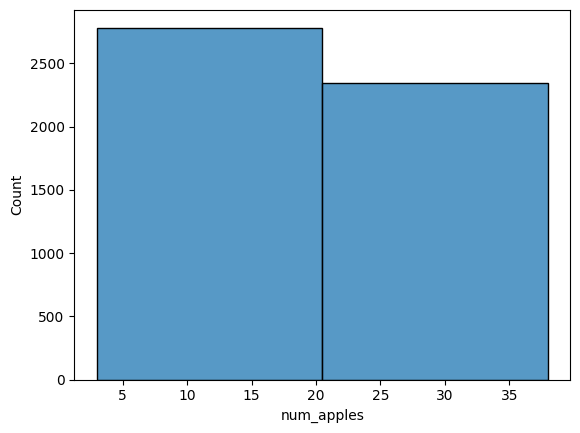

In [8]:
sns.histplot(data=spend_n_save_df, x='num_apples', bins=2)

Now, by setting `bins=2`, we have a histogram that is pretty terrible. We can't really see where the average might be and it's impossible to know that stores selling close to **0** apples are quite rare.

Now let's see what happens when we increase the number of bins to **10** with `bins=10`.

<Axes: xlabel='num_apples', ylabel='Count'>

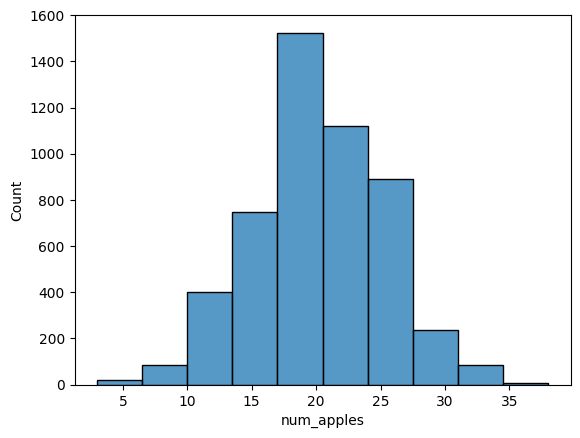

In [9]:
sns.histplot(data=spend_n_save_df, x='num_apples', bins=10)

Now, even with just 10 bins, we can see trends in the data. It's now clear that average should be close to **20** and that stores with close to **0** apples for sale are relatively rare.

# Double BAM!!

Now that we know one way to adjust the number of bins in a histogram, let's learn how to calculate probabilities from them them, and the data in general.

----

# Calculating probabilities from the data

Now, because we have a histogram, in theory, we could use it to calculate probabilities. However, calculating probabilities directly from the data itself is way, way easier to do, and way, way more flexible. Instead of being limited by the bins, when we calculate probabilities directly from the data, we can pick any value.

For example, the probability of walking into a **Spend-n-Save** store that sells at least **32** apples is the number of stores that sell at least **32** apples divided by the total number of stores.

In order to do this in `python`, we can use the `sum()` method to count the number of rows in the dataset with **32** or more appples. We do this with a relatively subtle command: `(spend_n_save_df['num_apples'] >= 32).sum()`. This works because `spend_n_save_df['num_apples'] >= 32` returns a list of TRUEs and FALSEs that reflect whether or not a row had `num_apples >= 32`. Numerically, `TRUE = 1` and `FALSE = 0`, so if we add up all the TRUEs, then we add up all the 1s, and this gives us the number of rows where `num_apples >= 32`.

In [10]:
# count the number of rows in the dataset where num_apples >= 32
num_stores = (spend_n_save_df['num_apples'] >= 32).sum()

# now print out the number of rows
print(f"The number of rows with num_apples >= 32: {num_stores}")

The number of rows with num_apples >= 32: 55


Now we just divide `num_stores` by the total number of rows in the dataset, which we can get with the `nrow()` function.

In [11]:
num_stores / len(spend_n_save_df)

np.float64(0.01073589693538942)

Now let's round that to the nearest 100th...

In [12]:
round(num_stores / len(spend_n_save_df), 2)

np.float64(0.01)

...and the probability that we might randomly walk into a **Spend-n-Save** store and see **32** or more apples for sale is **0.01**.

# TRIPLE BAM!!!

----

# Draw histograms of the estimated standard deviations we calculated in Chapter 1.

In Chapter 1, we ended the exercises by calculating a lot of **Estimated Standard Deviations** to compare what happens when we divide the **sum of the squared residuals** by `n` or `n-1`. Now let's pair those results with histograms to get more insight into why we divide by `n-1` instead of `n` when we estimate the **Standard Deviation**.

First, let's re-create the original data. We can do this because we use `np.random.seed()` to ensure that we get the same sequence of random numbers each time we run the program.

In [13]:
spend_n_save_df.head()

,id,num_apples
0,1,27
1,2,17
2,3,22
3,4,23
4,5,22


In [14]:
max_samples = 1000  # this is how many times we'll get a sample of random values.

# we'll save all of the estimated standard deviations in these lists.
estimated_sds_with_n_minus_1 = [0] * max_samples
estimated_sds_with_n = [0] * max_samples

np.random.seed(42)

for i in range(max_samples):
    
    ## get a sample of random values...
    rand_sample = spend_n_save_df.num_apples.sample(n=5)
    
    # Standard deviation with n-1 (estimated standard deviation)
    estimated_sds_with_n_minus_1[i] = statistics.stdev(rand_sample)

    # Standard deviation with n
    estimated_sds_with_n[i] = statistics.pstdev(rand_sample)

Now let's calculate an print the average standard deviations that we just calculated for both equations...

In [15]:
# lastly, print out the average sd when we divide by n-1...
print(f"Average SD with n-1: {round(np.mean(estimated_sds_with_n_minus_1), 1)}")

# ...and when we divide by n
print(f"Average SD with n: {round(np.mean(estimated_sds_with_n), 1)}")

Average SD with n-1: 4.8
Average SD with n: 4.3


Now let's draw histograms of the data, dividing by `n - 1` and `n`, while also super imposing the population standard deviation on top. So, first let's calculate the population standard deviation.

In [16]:
## calculate the population standard deviation and save it in 
## a variable called pop_sd
pop_sd = statistics.pstdev(spend_n_save_df.num_apples)

## print out the population standard deviation
pop_sd

5.038359554122998

Now let's draw the histograms with the population standard deviation on top.

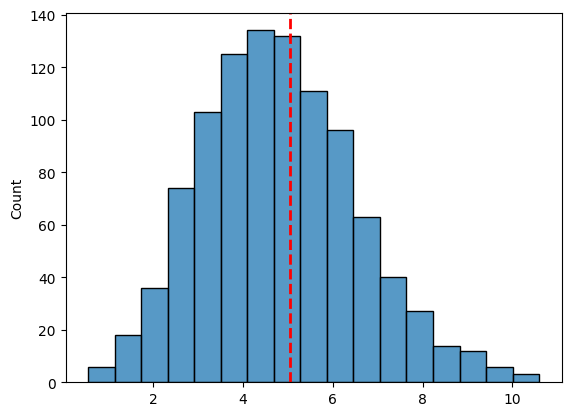

In [17]:
my_hist = sns.histplot(data=estimated_sds_with_n_minus_1, bins='scott')
my_hist.axvline(x=pop_sd, color='red', linestyle='--', linewidth=2)

The histogram we just drew, for the `n-1` data is relatively symmetrical around the **Population Standard Deviation**, which, if you remember, is **5**. This means that when we divide by `n-1`, we the **Estimated Standard Deviations** tend to underestimate the **Population Standard Deviations** as frequently as it underestimates them. In other words, the **Estimated Standard Deviations** are not biased to being less than or greater than the **Population Standard Deviation**.

Now let's see what the histogram looks like for the when we divided the **sum of the squared residuals** by `n`.

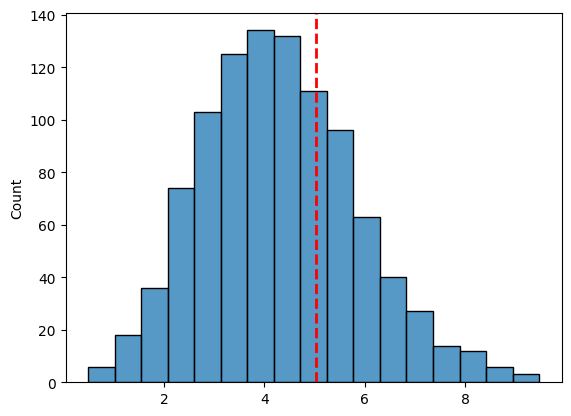

In [18]:
my_hist = sns.histplot(data=estimated_sds_with_n, bins='scott')
my_hist.axvline(x=pop_sd, color='red', linestyle='--', linewidth=2)

When we divid by `n` instead of `n-1`, we no longer get histogram that is symmetrical around the **Population Standard Deviation**. Instead, it seems squewed towards lower values. In other words, when we divide by `n`, it looks like we tend to underestimate the **Population Standard Deviation** more frequently than the overestimate it, and, as as result, we would call these estimates biased.

# bam.

----